# Time Series Analysis of Economic Development Dynamics in Central America

### Fourth Notebook: Forecasting and High-Level Economic Insights

This fourth notebook builds on the diagnostic results of Notebook 3 and extends the analysis toward a simple and interpretable forecasting framework for short-term economic dynamics in Central America. While the previous stage focused on identifying the statistical properties of the data, particularly the distinction between non-stationary levels and stationary growth rates, this phase applies these findings in a predictive context.

Forecasting is conducted exclusively on growth-rate variables, which were shown to be stationary and mean-reverting. This ensures consistency with the underlying time series structure and avoids modeling issues associated with non-stationary level variables, which are instead used for long-term interpretation.

The objective is not predictive optimization, but to assess the degree of short-term predictability in macroeconomic dynamics using simple and transparent models. This allows for a consistent comparison of forecasting performance across countries and provides additional insight into differences in economic volatility and structural behavior within the region.

**Author:** J-F Jutras  
**Date:** May 2026  
**Dataset:** UN National Accounts Main Aggregates Database (Central America subset)

## 4.1-Data Loading and Overview

In [1]:
import pandas as pd
import sys

# File path (Kaggle dataset)
file_path = "/kaggle/input/datasets/jfjutras07/timeseries-fe/central_america_timeseries_feature_engineering.csv"

# Load dataset
df = pd.read_csv(file_path)

# Load custom library from GitHub
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

# Add to Python path
sys.path.append("/kaggle/working/jfj-utils")

# Preview
display(df.head())
display(df.tail())
df.info()

Cloning into 'jfj-utils'...
remote: Enumerating objects: 3527, done.
remote: Counting objects: 100% (267/267), done.
remote: Compressing objects: 100% (180/180), done.
remote: Total 3527 (delta 211), reused 87 (delta 87), pack-reused 3260 (from 4)
Receiving objects: 100% (3527/3527), 1.18 MiB | 6.54 MiB/s, done.
Resolving deltas: 100% (2322/2322), done.


,Country,Year,Population,Gross Domestic Product (GDP),Per capita GNI,Gross capital formation,Exports of goods and services,Imports of goods and services,Final consumption expenditure,log_Gross Domestic Product (GDP),...,lag1_Exports of goods and services,lag1_Imports of goods and services,lag1_Final consumption expenditure,lag1_Per capita GNI,lag1_growth_Gross Domestic Product (GDP),lag1_growth_Gross capital formation,lag1_growth_Exports of goods and services,lag1_growth_Imports of goods and services,lag1_growth_Final consumption expenditure,lag1_growth_Per capita GNI
0,Belize,1970,120905,27917782.0,195,7450178.0,10317179.0,12335045.0,21072623.0,17.144774,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Belize,1971,123091,35385285.0,245,9299593.0,13474524.0,15709957.0,26315597.0,17.381807,...,10317179.0,12335045.0,21072623.0,195.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Belize,1972,125054,46000141.0,315,12422347.0,18383266.0,21233992.0,33738204.0,17.644155,...,13474524.0,15709957.0,26315597.0,245.0,0.267482,0.248238,0.306028,0.273604,0.248805,0.256410
3,Belize,1973,126875,74809672.0,514,20028373.0,24555373.0,31414706.0,58898086.0,18.130458,...,18383266.0,21233992.0,33738204.0,315.0,0.299979,0.335795,0.364298,0.351626,0.282061,0.285714
4,Belize,1974,128620,99801545.0,639,25015682.0,41368811.0,44947663.0,70891032.0,18.418694,...,24555373.0,31414706.0,58898086.0,514.0,0.626292,0.612286,0.335746,0.479454,0.745739,0.631746


,Country,Year,Population,Gross Domestic Product (GDP),Per capita GNI,Gross capital formation,Exports of goods and services,Imports of goods and services,Final consumption expenditure,log_Gross Domestic Product (GDP),...,lag1_Exports of goods and services,lag1_Imports of goods and services,lag1_Final consumption expenditure,lag1_Per capita GNI,lag1_growth_Gross Domestic Product (GDP),lag1_growth_Gross capital formation,lag1_growth_Exports of goods and services,lag1_growth_Imports of goods and services,lag1_growth_Final consumption expenditure,lag1_growth_Per capita GNI
359,Panama,2017,4096063,6.220273e+10,14074,2.595785e+10,2.600303e+10,2.837949e+10,3.862134e+10,24.853665,...,2.430551e+10,2.631063e+10,3.646051e+10,13168.0,0.070547,0.014051,-0.057694,-0.069105,0.090505,0.069005
360,Panama,2018,4165255,6.492941e+10,14320,2.693338e+10,2.778392e+10,3.064638e+10,4.085849e+10,24.896567,...,2.600303e+10,2.837949e+10,3.862134e+10,14074.0,0.074170,0.106835,0.069841,0.078632,0.059265,0.068803
361,Panama,2019,4232532,6.698443e+10,14596,2.565666e+10,2.760294e+10,2.932200e+10,4.304682e+10,24.927726,...,2.778392e+10,3.064638e+10,4.085849e+10,14320.0,0.043835,0.037582,0.068488,0.079878,0.057925,0.017479
362,Panama,2020,4294396,5.397704e+10,12048,1.298641e+10,2.137917e+10,1.860550e+10,3.821697e+10,24.711825,...,2.760294e+10,2.932200e+10,4.304682e+10,14596.0,0.031650,-0.047403,-0.006514,-0.043215,0.053559,0.019274
363,Panama,2021,4351267,6.360507e+10,14012,1.622814e+10,3.247930e+10,2.648142e+10,4.137905e+10,24.875959,...,2.137917e+10,1.860550e+10,3.821697e+10,12048.0,-0.194185,-0.493839,-0.225475,-0.365476,-0.112200,-0.174568


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 32 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    364 non-null    object 
 1   Year                                       364 non-null    int64  
 2   Population                                 364 non-null    int64  
 3   Gross Domestic Product (GDP)               364 non-null    float64
 4   Per capita GNI                             364 non-null    int64  
 5   Gross capital formation                    364 non-null    float64
 6   Exports of goods and services              364 non-null    float64
 7   Imports of goods and services              364 non-null    float64
 8   Final consumption expenditure              364 non-null    float64
 9   log_Gross Domestic Product (GDP)           364 non-null    float64
 10  log_Exports of goods and s

## 4.2-Forecasting Variable Selection

Forecasting models must remain consistent with the statistical properties identified in Notebook 3. The analysis showed that macroeconomic variables expressed in levels are predominantly non-stationary, while growth-rate transformations exhibit stationary and mean-reverting behavior.

As a result, only growth-rate variables are considered suitable for short-term forecasting. These variables capture the cyclical component of economic dynamics and allow for meaningful time series modeling without violating stationarity assumptions.

In this notebook, GDP growth is selected as the primary forecasting target. It represents a broad measure of economic performance and enables consistent comparison across countries within the region.

In [2]:
# Define target variable (stationary series for forecasting)
target = "growth_Gross Domestic Product (GDP)"

# Keep only relevant columns for forecasting
df_model = df[["Country", "Year", target]].copy()

# Remove missing values introduced by lag/growth construction
df_model = df_model.dropna()

# Ensure proper ordering (important for time series consistency)
df_model = df_model.sort_values(["Country", "Year"]).reset_index(drop=True)

# Quick validation
display(df_model.head(10))
print("Final dataset shape:", df_model.shape)

,Country,Year,growth_Gross Domestic Product (GDP)
0,Belize,1971,0.267482
1,Belize,1972,0.299979
2,Belize,1973,0.626292
3,Belize,1974,0.334073
4,Belize,1975,0.158618
5,Belize,1976,-0.211737
6,Belize,1977,0.285351
7,Belize,1978,0.141777
8,Belize,1979,0.168874
9,Belize,1980,0.378895


Final dataset shape: (357, 3)


This setup ensures that all forecasting models are applied on a consistent and statistically valid time series structure across countries.

## 4.3-Panel Structuring for Forecasting

To ensure proper time series consistency, the dataset is structured as a country-level panel and ordered chronologically. This step is essential for preserving temporal dependence within each country and preventing any form of cross-temporal misalignment in forecasting exercises.

In a panel time series context, each country is treated as an independent time series. Proper sorting ensures that all lag-based or sequential operations respect the temporal ordering of observations, which is critical for valid out-of-sample forecasting.

In [3]:
# Ensure chronological ordering within each country
df_model = df_model.sort_values(["Country", "Year"]).reset_index(drop=True)

# Validate structure
display(df_model.head(10))

# Check number of observations per country (sanity check)
print(df_model.groupby("Country").size())

,Country,Year,growth_Gross Domestic Product (GDP)
0,Belize,1971,0.267482
1,Belize,1972,0.299979
2,Belize,1973,0.626292
3,Belize,1974,0.334073
4,Belize,1975,0.158618
5,Belize,1976,-0.211737
6,Belize,1977,0.285351
7,Belize,1978,0.141777
8,Belize,1979,0.168874
9,Belize,1980,0.378895


Country
Belize         51
Costa Rica     51
El Salvador    51
Guatemala      51
Honduras       51
Nicaragua      51
Panama         51
dtype: int64


## 4.4-Baseline Forecasting Model (Random Walk)

Before introducing structured time series models, it is necessary to define a simple benchmark for forecasting performance. In time series analysis, the random walk model is a standard reference model, particularly in contexts where autocorrelation is weak or unstable.

The random walk assumes that the best prediction for the next period is simply the most recent observed value. In the context of GDP growth, this translates into a persistence assumption, where short-term economic dynamics are primarily driven by the latest available information.

Given the results from Notebook 3, which showed limited and inconsistent autocorrelation in growth rates across countries, this benchmark provides a meaningful reference point for evaluating whether more structured models can extract additional predictive signal.

The objective of this baseline is not accuracy, but calibration: it defines a minimum performance threshold that any more advanced model must surpass to demonstrate meaningful predictive value. This model is also used as a visual and numerical baseline in the evaluation stage to assess whether more structured approaches provide incremental information.

In [4]:
# Random Walk Forecast:
# Forecast at time t = value at time t-1 within each country

df_model["rw_forecast"] = (
    df_model
    .groupby("Country")[target]
    .shift(1)
)

# Remove first observation per country (no lag available)
df_rw = df_model.dropna().copy()

# Ensure structure consistency
display(df_rw.head(10))
print("Shape after random walk construction:", df_rw.shape)

,Country,Year,growth_Gross Domestic Product (GDP),rw_forecast
1,Belize,1972,0.299979,0.267482
2,Belize,1973,0.626292,0.299979
3,Belize,1974,0.334073,0.626292
4,Belize,1975,0.158618,0.334073
5,Belize,1976,-0.211737,0.158618
6,Belize,1977,0.285351,-0.211737
7,Belize,1978,0.141777,0.285351
8,Belize,1979,0.168874,0.141777
9,Belize,1980,0.378895,0.168874
10,Belize,1981,-0.009245,0.378895


Shape after random walk construction: (350, 4)


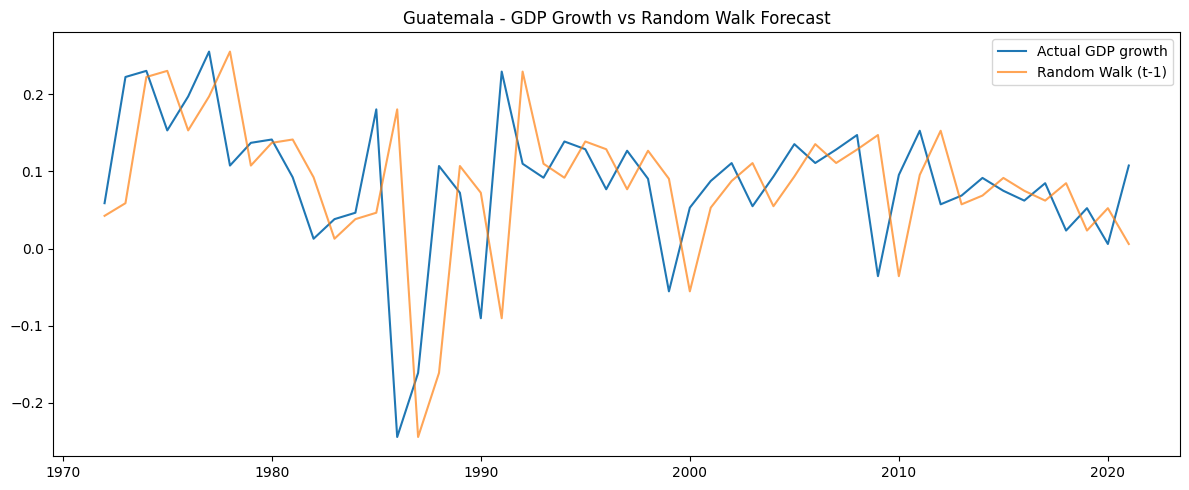

In [5]:
import matplotlib.pyplot as plt

country = "Guatemala"

df_plot = df_rw[df_rw["Country"] == country].copy()

plt.figure(figsize=(12,5))
plt.plot(df_plot["Year"], df_plot[target], label="Actual GDP growth")
plt.plot(df_plot["Year"], df_plot["rw_forecast"], label="Random Walk (t-1)", alpha=0.7)

plt.title(f"{country} - GDP Growth vs Random Walk Forecast")
plt.legend()
plt.tight_layout()
plt.show()

The random walk closely tracks short-term movements but does not systematically anticipate turning points, which is expected given the construction of growth-rate data.

## 4.5-Autoregressive Model

To extend the baseline specification, we introduce a simple autoregressive model of order one (AR(1)). This model allows current GDP growth to depend on its immediate past value, capturing potential short-term persistence in economic dynamics.

This specification is consistent with the results from Notebook 3, where autocorrelation analysis showed weak but non-negligible short-term dependence in GDP growth for certain countries. The AR(1) model therefore provides a structured way to estimate this persistence directly from the data. However, the strength of this persistence varies significantly across countries, suggesting heterogeneous short-term dynamics within the region.

Unlike the random walk model, which assumes full persistence, the AR(1) model estimates the strength of temporal dependence, allowing for more flexible dynamics while remaining fully interpretable.

The model is estimated separately for each country using a strict chronological train/test split to ensure out-of-sample validity. Forecasts are generated on the test horizon without re-estimation, allowing for a consistent comparison with the baseline model.

In [6]:
from statsmodels.tsa.ar_model import AutoReg

results = []

for country in df_rw["Country"].unique():
    
    # Filter country-specific data
    df_c = df_rw[df_rw["Country"] == country].copy()
    df_c = df_c.sort_values("Year").reset_index(drop=True)
    
    # Train/test split (chronological)
    train_size = int(len(df_c) * 0.8)
    train = df_c.iloc[:train_size]
    test = df_c.iloc[train_size:]
    
    # Fit AR(1) model
    model = AutoReg(train[target], lags=1, old_names=False).fit()
    
    # Forecast on test horizon
    forecast = model.predict(
        start=len(train),
        end=len(train) + len(test) - 1
    )
    
    # Store results
    df_c["ar1_forecast"] = pd.NA
    df_c.loc[test.index, "ar1_forecast"] = forecast.values
    
    results.append(df_c)

# Combine results
df_ar1 = pd.concat(results, ignore_index=True)

# Keep only test period
df_ar1 = df_ar1.dropna(subset=["ar1_forecast"]).copy()

display(df_ar1.head(10))
print("Final AR(1) evaluation dataset shape:", df_ar1.shape)

,Country,Year,growth_Gross Domestic Product (GDP),rw_forecast,ar1_forecast
40,Belize,2012,0.045998,0.046506,0.083552
41,Belize,2013,0.066378,0.045998,0.09642
42,Belize,2014,0.053409,0.066378,0.10089
43,Belize,2015,0.033892,0.053409,0.102442
44,Belize,2016,0.021719,0.033892,0.102982
45,Belize,2017,0.012306,0.021719,0.103169
46,Belize,2018,0.012601,0.012306,0.103234
47,Belize,2019,0.043896,0.012601,0.103257
48,Belize,2020,-0.139239,0.043896,0.103264
49,Belize,2021,0.197828,-0.139239,0.103267


Final AR(1) evaluation dataset shape: (70, 5)


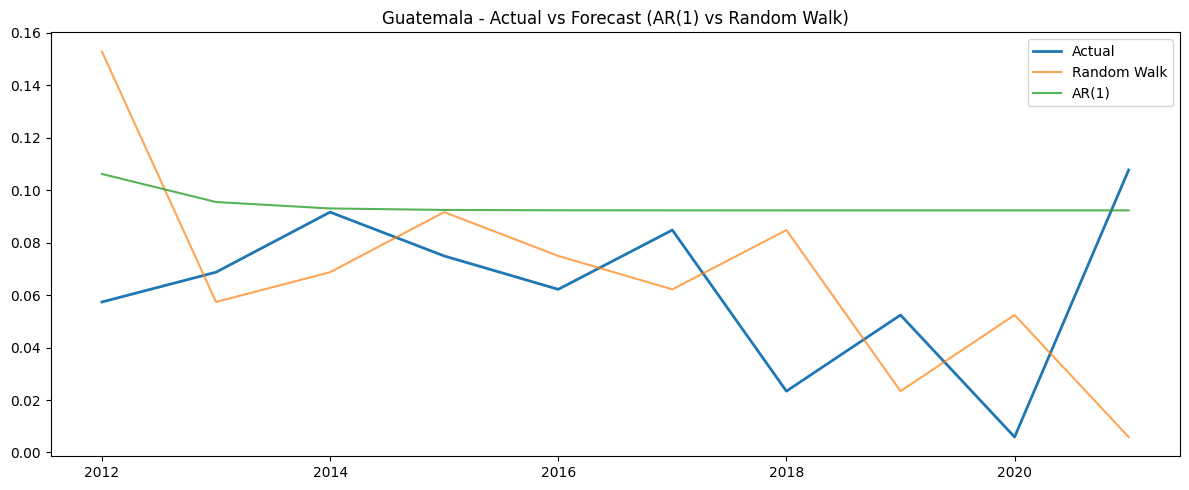

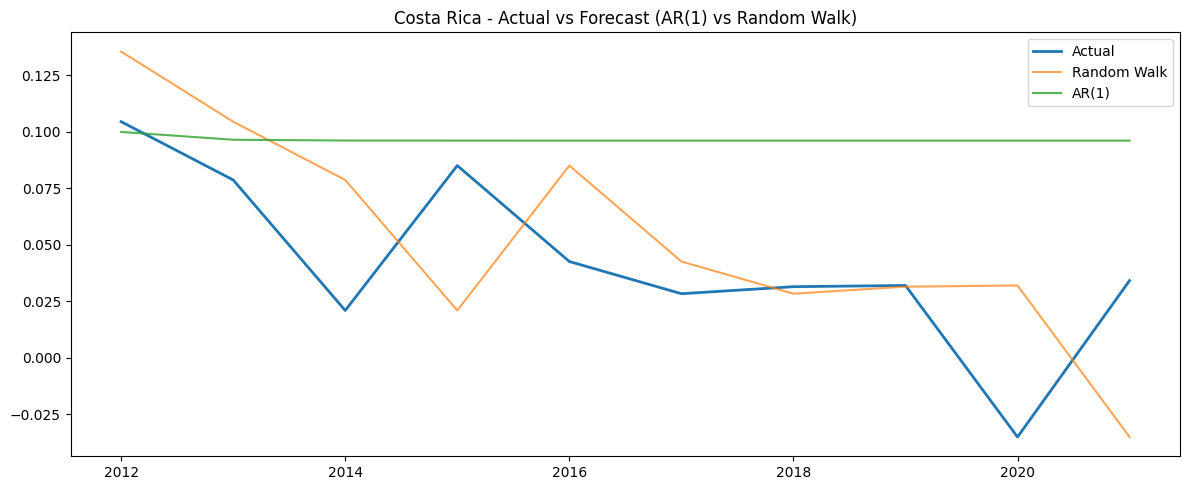

In [7]:
import matplotlib.pyplot as plt

countries = ["Guatemala", "Costa Rica"]

for country in countries:
    
    df_plot = df_ar1[df_ar1["Country"] == country].copy()
    
    plt.figure(figsize=(12,5))
    
    plt.plot(df_plot["Year"], df_plot[target], label="Actual", linewidth=2)
    plt.plot(df_plot["Year"], df_plot["rw_forecast"], label="Random Walk", alpha=0.7)
    plt.plot(df_plot["Year"], df_plot["ar1_forecast"], label="AR(1)", alpha=0.8)

    plt.title(f"{country} - Actual vs Forecast (AR(1) vs Random Walk)")
    plt.legend()
    plt.tight_layout()
    plt.show()

Guatemala exhibits almost flat AR(1) forecasts, indicating weak persistence in growth dynamics.

Costa Rica shows slightly more variation, but the model still fails to capture meaningful short-term fluctuations.

This highlights that autoregressive structure is not uniformly informative across countries.

## 4.6-ARIMA Robustness Check

To complement the baseline Random Walk and the AR(1) specification, we estimate a simple ARIMA model to further assess the short-term memory structure of GDP growth dynamics across Central America.

Given the stationarity properties identified in Notebook 3, the integration order is set to zero (d = 0), and the model is restricted to a low-order specification to preserve interpretability.

The goal is not to optimize forecasting performance, but to verify whether allowing a slightly more flexible autoregressive structure improves predictive accuracy compared to simpler benchmarks.

In this context, ARIMA serves as a robustness check for short-memory dynamics rather than a full structural modeling framework.

We focus on ARIMA(1,0,1), which generalizes the AR(1) model by adding a moving average component while remaining consistent with stationary data behavior.

In [8]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

target = "growth_Gross Domestic Product (GDP)"

results_arima = []

for country in df_rw["Country"].unique():
    
    # Filter country data
    df_c = df_rw[df_rw["Country"] == country].copy()
    df_c = df_c.sort_values("Year").reset_index(drop=True)
    
    # Train / Test split
    train_size = int(len(df_c) * 0.8)
    train = df_c.iloc[:train_size]
    test = df_c.iloc[train_size:]
    
    # Fit ARIMA(1,0,1)
    model = ARIMA(train[target], order=(1, 0, 1))
    model_fit = model.fit()
    
    # Forecast
    forecast = model_fit.forecast(steps=len(test))
    
    # Store results
    df_c["arima_forecast"] = pd.NA
    df_c.loc[test.index, "arima_forecast"] = forecast.values
    
    results_arima.append(df_c)

# Combine results
df_arima = pd.concat(results_arima, ignore_index=True)

# Keep test period only
df_arima = df_arima.dropna(subset=["arima_forecast"]).copy()

display(df_arima.head())
print(df_arima.shape)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,Country,Year,growth_Gross Domestic Product (GDP),rw_forecast,arima_forecast
40,Belize,2012,0.045998,0.046506,0.091279
41,Belize,2013,0.066378,0.045998,0.107739
42,Belize,2014,0.053409,0.066378,0.111258
43,Belize,2015,0.033892,0.053409,0.112011
44,Belize,2016,0.021719,0.033892,0.112172


(70, 5)


The presence of initialization warnings reflects weak persistence and limited sample size rather than model misspecification. These numerical artifacts are common in low-frequency macroeconomic panel time series and do not affect the validity of forecast comparisons.

Importantly, ARIMA does not improve predictive accuracy relative to simpler models, reinforcing the conclusion that short-term GDP growth dynamics in Central America are largely dominated by stochastic shocks rather than persistent temporal structure.

## 4.7-Forecast Evaluation

Forecast performance is evaluated using the Root Mean Squared Error (RMSE), computed on the out-of-sample test period for each country.

This evaluation framework ensures a consistent comparison across models while respecting the temporal structure of the data and avoiding any look-ahead bias.

Three forecasting approaches are compared:

- Random Walk (naive persistence benchmark)
- AR(1) (short-memory autoregressive structure)
- ARIMA(1,0,1) (extended short-memory specification)

The objective is not to identify the best predictive model, but to assess whether increasing model complexity leads to meaningful gains in predictive accuracy given the statistical properties of GDP growth identified in Notebook 3.

All models are evaluated independently for each country in order to capture heterogeneity in economic dynamics and shock transmission mechanisms.

In [9]:
from sklearn.metrics import mean_squared_error

# Build evaluation table

# Start from ARIMA dataframe
df_eval_base = df_arima.copy()

# Ensure AR(1) exists
if "ar1_forecast" not in df_eval_base.columns:
    df_eval_base = df_eval_base.merge(
        df_ar1[["Country", "Year", "ar1_forecast"]],
        on=["Country", "Year"],
        how="left"
    )

# Evaluation
results = []

for country in df_eval_base["Country"].unique():
    
    df_c = df_eval_base[df_eval_base["Country"] == country].copy()
    
    # test period only
    df_test = df_c.dropna(subset=["arima_forecast", "ar1_forecast", "rw_forecast"])
    
    # RMSE Random Walk
    rmse_rw = np.sqrt(mean_squared_error(
        df_test[target],
        df_test["rw_forecast"]
    ))
    
    # RMSE AR(1)
    rmse_ar1 = np.sqrt(mean_squared_error(
        df_test[target],
        df_test["ar1_forecast"]
    ))
    
    # RMSE ARIMA
    rmse_arima = np.sqrt(mean_squared_error(
        df_test[target],
        df_test["arima_forecast"]
    ))
    
    results.append({
        "Country": country,
        "RMSE_RandomWalk": rmse_rw,
        "RMSE_AR1": rmse_ar1,
        "RMSE_ARIMA(1,0,1)": rmse_arima
    })

df_eval = pd.DataFrame(results).round(4)

display(df_eval)

,Country,RMSE_RandomWalk,RMSE_AR1,"RMSE_ARIMA(1,0,1)"
0,Belize,0.1222,0.1018,0.1079
1,Costa Rica,0.0452,0.0655,0.0665
2,El Salvador,0.0910,0.0747,0.0746
3,Guatemala,0.0528,0.0429,0.0406
4,Honduras,0.0915,0.0682,0.0681
5,Nicaragua,0.0534,0.0546,0.0547
6,Panama,0.1392,0.0981,0.0976


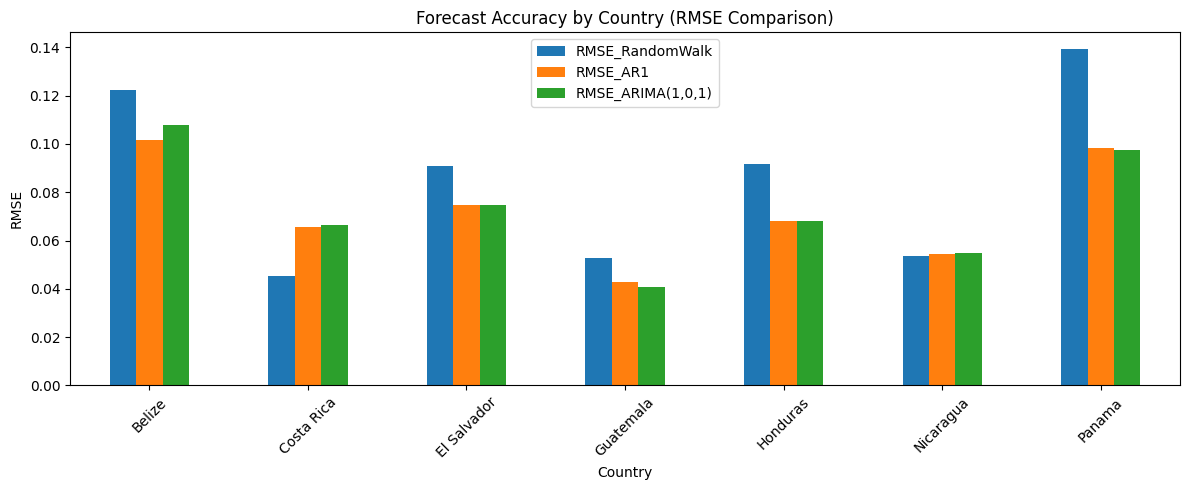

In [10]:
df_eval_plot = df_eval.set_index("Country")

df_eval_plot[[
    "RMSE_RandomWalk",
    "RMSE_AR1",
    "RMSE_ARIMA(1,0,1)"
]].plot(kind="bar", figsize=(12,5))

plt.title("Forecast Accuracy by Country (RMSE Comparison)")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

The results reveal heterogeneous forecasting performance across countries. In Belize, El Salvador, Guatemala, Honduras, and Panama, both AR(1) and ARIMA models generally outperform the Random Walk, suggesting the presence of weak but exploitable short-term persistence in GDP growth dynamics.

In contrast, Costa Rica and Nicaragua show little to no improvement over the Random Walk benchmark. In these cases, GDP growth behaves closer to a near-random process, where short-term dynamics are dominated by stochastic shocks rather than persistent structure.

Across countries, ARIMA(1,0,1) does not significantly outperform the simpler AR(1) specification. This indicates that adding a moving average component does not materially improve predictive accuracy, consistent with the weak autocorrelation structure identified in Notebook 3.

## 4.8-Summary - Notebook 4

| Dimension               | Finding                                                      | Interpretation                                                                                             |
| ----------------------- | ------------------------------------------------------------ | ---------------------------------------------------------------------------------------------------------- |
| Forecasting approach    | Simple time series models (Random Walk, AR(1), ARIMA(1,0,1)) | Focus on interpretability and consistency with stationarity properties rather than predictive optimization |
| Target variable         | GDP growth (stationary)                                      | Appropriate transformation for modeling short-term economic dynamics                                       |
| Baseline performance    | Random Walk remains highly competitive in several countries  | Indicates strong short-run information content in last observed value and limited exploitable structure    |
| AR(1) performance       | Moderate and inconsistent improvement over baseline          | Suggests weak and unstable short-term persistence in GDP growth                                            |
| ARIMA robustness        | No systematic gain over AR(1)                                | Confirms limited value of additional short-memory structure in this context                                |
| Cross-country variation | Strong heterogeneity in forecasting performance              | Reflects differences in economic structure, volatility, and shock transmission mechanisms                  |
| Predictability          | Limited and non-uniform across countries                     | Short-term dynamics are partially predictable but largely dominated by stochastic shocks                   |
| Key structural insight  | Weak mean reversion in growth rates                          | Consistent with stationarity but limited and unstable autocorrelation patterns                             |
| Economic implication    | Shock-driven short-term dynamics                             | Regional growth processes combine long-run structural trends with highly volatile short-term fluctuations  |


This notebook deliberately focuses on simple time series models rather than advanced predictive techniques. The main objective of this project is not to maximize forecasting accuracy, but to understand the underlying structure of economic dynamics in Central America.

The diagnostic work in Notebook 3 showed that GDP growth is largely stationary with weak and inconsistent autocorrelation patterns across countries. This implies that short-term economic movements are driven more by external shocks than by stable internal dynamics, which naturally limits the potential gains from complex predictive modeling.

For this reason, the analysis prioritizes interpretability and structural consistency over model complexity. Simple models such as the random walk and AR(1) are sufficient to benchmark predictability while remaining aligned with the statistical properties of the data.